In [ ]:
import pandas as pd
import numpy as np

In [ ]:
crime = pd.read_csv('CRIME_FINALLL.csv')
income = pd.read_csv('INCOME_FINAL.csv')
permits = pd.read_csv('PERMIT_FINALL.csv')
transit = pd.read_csv('TRANSIT_FINALL.csv')
economic = pd.read_csv('ECONOMIC_FINALL.csv')


In [ ]:
print("Crime shape:", crime.shape)
print("Income shape:", income.shape)
print("Permits shape:", permits.shape)
print("Transit shape:", transit.shape)
print("Economic shape:", economic.shape)

Crime shape: (250, 6)
Income shape: (25, 4)
Permits shape: (500, 6)
Transit shape: (1000, 11)
Economic shape: (25, 4)


Standardize borough names

In [ ]:
crime['boro_nm'] = crime['boro_nm'].str.upper().str.strip()
income['borough'] = income['borough'].str.upper().str.strip()
permits['borough'] = permits['borough'].str.upper().str.strip()
transit['borough'] = transit['borough'].str.upper().str.strip()
economic['area_name'] = economic['area_name'].str.upper().str.strip()


In [ ]:
# Aggregate crime
crime_summary = crime.groupby('boro_nm').size().reset_index(name='crime_total')

# Latest income year
latest_year = income['year'].max()
income_latest = income[income['year'] == latest_year][
    ['borough','median_income','growth_percent']
]

# Permit pressure
permits['proposed_dwelling_units'] = pd.to_numeric(
    permits['proposed_dwelling_units'], errors='coerce'
)

permit_summary = permits.groupby('borough')['proposed_dwelling_units'].sum().reset_index()
permit_summary.rename(columns={'proposed_dwelling_units':'permit_units'}, inplace=True)

# Transit intensity
transit_summary = transit.groupby('borough')['ridership'].sum().reset_index()
transit_summary.rename(columns={'ridership':'total_ridership'}, inplace=True)

# Economic (latest unemployment)
economic['year'] = economic['attribute'].str.extract(r'(\d+)')
economic['year'] = pd.to_numeric(economic['year'])

latest_econ_year = economic['year'].max()
economic_latest = economic[economic['year'] == latest_econ_year][
    ['area_name','value']
]
economic_latest.rename(columns={'area_name':'borough','value':'unemployment_rate'}, inplace=True)

print("Aggregation Complete")

Aggregation Complete


MERGING

In [ ]:
# Create base borough table
boroughs = ['MANHATTAN','BROOKLYN','BRONX','QUEENS','STATEN ISLAND']
base_df = pd.DataFrame({'borough': boroughs})

# Merge everything
df = base_df.merge(crime_summary, left_on='borough', right_on='boro_nm', how='left')
df = df.merge(income_latest, on='borough', how='left')
df = df.merge(permit_summary, on='borough', how='left')
df = df.merge(transit_summary, on='borough', how='left')
df = df.merge(economic_latest, on='borough', how='left')

# Drop duplicate column
df = df.drop(columns=['boro_nm'])

# Fill missing values
df.fillna(0, inplace=True)

df

,borough,crime_total,median_income,growth_percent,permit_units,total_ridership,unemployment_rate
0,MANHATTAN,50,103485.86,2.25,2472,504147,7.23
1,BROOKLYN,50,115273.38,2.92,2447,510479,10.00
2,BRONX,50,98358.83,4.02,2487,498233,4.59
3,QUEENS,50,119997.35,2.49,2401,484528,7.74
4,STATEN ISLAND,50,92339.13,2.35,2606,530319,3.09


Normalization & Index Engineering

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

# Normalize raw indicators
df[['crime_norm',
    'income_norm',
    'growth_norm',
    'permit_norm',
    'transit_norm',
    'unemployment_norm']] = scaler.fit_transform(
    df[['crime_total',
        'median_income',
        'growth_percent',
        'permit_units',
        'total_ridership',
        'unemployment_rate']]
)

# Convert crime to safety index (lower crime = higher safety)
df['safety_index'] = 1 - df['crime_norm']

# Convert unemployment to economic strength (lower unemployment = stronger economy)
df['economic_strength_index'] = 1 - df['unemployment_norm']

df

,borough,crime_total,median_income,growth_percent,permit_units,total_ridership,unemployment_rate,crime_norm,income_norm,growth_norm,permit_norm,transit_norm,unemployment_norm,safety_index,economic_strength_index
0,MANHATTAN,50,103485.86,2.25,2472,504147,7.23,0.0,0.403017,0.000000,0.346341,0.428447,0.599132,1.0,0.400868
1,BROOKLYN,50,115273.38,2.92,2447,510479,10.00,0.0,0.829202,0.378531,0.224390,0.566727,1.000000,1.0,0.000000
2,BRONX,50,98358.83,4.02,2487,498233,4.59,0.0,0.217646,1.000000,0.419512,0.299295,0.217077,1.0,0.782923
3,QUEENS,50,119997.35,2.49,2401,484528,7.74,0.0,1.000000,0.135593,0.000000,0.000000,0.672938,1.0,0.327062
4,STATEN ISLAND,50,92339.13,2.35,2606,530319,3.09,0.0,0.000000,0.056497,1.000000,1.000000,0.000000,1.0,1.000000


RISK SCORE


In [ ]:
# Compute final Gentrification Risk Score

df['gentrification_risk'] = (
    0.20 * df['permit_norm'] +
    0.20 * df['growth_norm'] +
    0.20 * df['economic_strength_index'] +
    0.20 * df['transit_norm'] +
    0.20 * df['safety_index']
)


# Risk classification
def classify_risk(score):
    if score >= 0.75:
        return "Very High"
    elif score >= 0.60:
        return "High"
    elif score >= 0.40:
        return "Medium"
    else:
        return "Low"

df['risk_level'] = df['gentrification_risk'].apply(classify_risk)

df.sort_values(by='gentrification_risk', ascending=False)

,borough,crime_total,median_income,growth_percent,permit_units,total_ridership,unemployment_rate,crime_norm,income_norm,growth_norm,permit_norm,transit_norm,unemployment_norm,safety_index,economic_strength_index,gentrification_risk,risk_level
4,STATEN ISLAND,50,92339.13,2.35,2606,530319,3.09,0.0,0.000000,0.056497,1.000000,1.000000,0.000000,1.0,1.000000,0.811299,Very High
2,BRONX,50,98358.83,4.02,2487,498233,4.59,0.0,0.217646,1.000000,0.419512,0.299295,0.217077,1.0,0.782923,0.700346,High
0,MANHATTAN,50,103485.86,2.25,2472,504147,7.23,0.0,0.403017,0.000000,0.346341,0.428447,0.599132,1.0,0.400868,0.435131,Medium
1,BROOKLYN,50,115273.38,2.92,2447,510479,10.00,0.0,0.829202,0.378531,0.224390,0.566727,1.000000,1.0,0.000000,0.433930,Medium
3,QUEENS,50,119997.35,2.49,2401,484528,7.74,0.0,1.000000,0.135593,0.000000,0.000000,0.672938,1.0,0.327062,0.292531,Low


In [ ]:
df['temp_risk'] = (
    (1/5) * df['permit_norm'] +
    (1/5) * df['growth_norm'] +
    (1/5) * df['economic_strength_index'] +
    (1/5) * df['transit_norm'] +
    (1/5) * df['safety_index']
)

X = df[[
    'permit_norm',
    'growth_norm',
    'economic_strength_index',
    'transit_norm',
    'safety_index'
]]

y = df['temp_risk']



In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

weights = model.feature_importances_

for feature, weight in zip(X.columns, weights):
    print(feature, ":", weight)

permit_norm : 0.4214959983208497
growth_norm : 0.12256430003115244
economic_strength_index : 0.23128980244161684
transit_norm : 0.22464989920638112
safety_index : 0.0


In [ ]:
weights = weights / weights.sum()

In [ ]:
df['ml_risk'] = (
    weights[0] * df['permit_norm'] +
    weights[1] * df['growth_norm'] +
    weights[2] * df['economic_strength_index'] +
    weights[3] * df['transit_norm'] +
    weights[4] * df['safety_index']
)

# Risk classification
def classify_risk(score):
    if score >= 0.75:
        return "Very High"
    elif score >= 0.60:
        return "High"
    elif score >= 0.40:
        return "Medium"
    else:
        return "Low"

df['risk_level'] = df['gentrification_risk'].apply(classify_risk)

df.sort_values(by='gentrification_risk', ascending=False)



,borough,crime_total,median_income,growth_percent,permit_units,total_ridership,unemployment_rate,crime_norm,income_norm,growth_norm,permit_norm,transit_norm,unemployment_norm,safety_index,economic_strength_index,gentrification_risk,risk_level,temp_risk,ml_risk
4,STATEN ISLAND,50,92339.13,2.35,2606,530319,3.09,0.0,0.000000,0.056497,1.000000,1.000000,0.000000,1.0,1.000000,0.811299,Very High,0.811299,0.884360
2,BRONX,50,98358.83,4.02,2487,498233,4.59,0.0,0.217646,1.000000,0.419512,0.299295,0.217077,1.0,0.782923,0.700346,High,0.700346,0.547706
0,MANHATTAN,50,103485.86,2.25,2472,504147,7.23,0.0,0.403017,0.000000,0.346341,0.428447,0.599132,1.0,0.400868,0.435131,Medium,0.435131,0.334949
1,BROOKLYN,50,115273.38,2.92,2447,510479,10.00,0.0,0.829202,0.378531,0.224390,0.566727,1.000000,1.0,0.000000,0.433930,Medium,0.433930,0.268289
3,QUEENS,50,119997.35,2.49,2401,484528,7.74,0.0,1.000000,0.135593,0.000000,0.000000,0.672938,1.0,0.327062,0.292531,Low,0.292531,0.092265


Using  Pca

In [ ]:
X = df[[
    'permit_norm',
    'growth_norm',
    'economic_strength_index',
    'transit_norm',
    'safety_index'
]]

from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(X)

weights = pca.components_[0]

for feature, weight in zip(X.columns, weights):
    print(feature, ":", weight)

permit_norm : 0.6295100684925514
growth_norm : -0.09709657221315582
economic_strength_index : 0.5480633584602357
transit_norm : 0.5421400966947981
safety_index : 0.0


In [ ]:
import numpy as np

weights = np.abs(weights)
weights = weights / weights.sum()

In [ ]:
df['pca_risk'] = (
    weights[0] * df['permit_norm'] +
    weights[1] * df['growth_norm'] +
    weights[2] * df['economic_strength_index'] +
    weights[3] * df['transit_norm'] +
    weights[4] * df['safety_index']
)

# Risk classification
def classify_risk(score):
    if score >= 0.75:
        return "Very High"
    elif score >= 0.60:
        return "High"
    elif score >= 0.40:
        return "Medium"
    else:
        return "Low"

df['risk_level'] = df['gentrification_risk'].apply(classify_risk)

df.sort_values(by='gentrification_risk', ascending=False)



,borough,crime_total,median_income,growth_percent,permit_units,total_ridership,unemployment_rate,crime_norm,income_norm,growth_norm,permit_norm,transit_norm,unemployment_norm,safety_index,economic_strength_index,gentrification_risk,risk_level,temp_risk,ml_risk,pca_risk
4,STATEN ISLAND,50,92339.13,2.35,2606,530319,3.09,0.0,0.000000,0.056497,1.000000,1.000000,0.000000,1.0,1.000000,0.811299,Very High,0.811299,0.884360,0.949576
2,BRONX,50,98358.83,4.02,2487,498233,4.59,0.0,0.217646,1.000000,0.419512,0.299295,0.217077,1.0,0.782923,0.700346,High,0.700346,0.547706,0.524290
0,MANHATTAN,50,103485.86,2.25,2472,504147,7.23,0.0,0.403017,0.000000,0.346341,0.428447,0.599132,1.0,0.400868,0.435131,Medium,0.435131,0.334949,0.368781
1,BROOKLYN,50,115273.38,2.92,2447,510479,10.00,0.0,0.829202,0.378531,0.224390,0.566727,1.000000,1.0,0.000000,0.433930,Medium,0.433930,0.268289,0.267092
3,QUEENS,50,119997.35,2.49,2401,484528,7.74,0.0,1.000000,0.135593,0.000000,0.000000,0.672938,1.0,0.327062,0.292531,Low,0.292531,0.092265,0.105909


Feature Contribution Analyzer

In [ ]:
# Calculate contribution of each factor

df['contrib_permit'] = weights[0] * df['permit_norm']
df['contrib_income_growth'] = weights[1] * df['growth_norm']
df['contrib_economic'] = weights[2] * df['economic_strength_index']
df['contrib_transit'] = weights[3] * df['transit_norm']
df['contrib_safety'] = weights[4] * df['safety_index']

df[['borough',
    'contrib_permit',
    'contrib_income_growth',
    'contrib_economic',
    'contrib_transit',
    'contrib_safety',
    'gentrification_risk']]

df[['borough',
    'contrib_permit',
    'contrib_income_growth',
    'contrib_economic',
    'contrib_transit',
    'contrib_safety',
    'gentrification_risk']]

,borough,contrib_permit,contrib_income_growth,contrib_economic,contrib_transit,contrib_safety,gentrification_risk
0,MANHATTAN,0.120005,0.000000,0.120927,0.127849,0.0,0.435131
1,BROOKLYN,0.077749,0.020230,0.000000,0.169113,0.0,0.433930
2,BRONX,0.145358,0.053443,0.236179,0.089310,0.0,0.700346
3,QUEENS,0.000000,0.007247,0.098662,0.000000,0.0,0.292531
4,STATEN ISLAND,0.346492,0.003019,0.301662,0.298402,0.0,0.811299


DOMINANT RISK FACTOR

In [ ]:
# Identify dominant factor per borough

factor_cols = [
    'contrib_permit',
    'contrib_income_growth',
    'contrib_economic',
    'contrib_transit',
    'contrib_safety'
]

df['dominant_risk_driver'] = df[factor_cols].idxmax(axis=1)

df[['borough','gentrification_risk','dominant_risk_driver']]

,borough,gentrification_risk,dominant_risk_driver
0,MANHATTAN,0.435131,contrib_transit
1,BROOKLYN,0.433930,contrib_transit
2,BRONX,0.700346,contrib_economic
3,QUEENS,0.292531,contrib_economic
4,STATEN ISLAND,0.811299,contrib_permit


FUTURE  RISK PREDICTION

In [ ]:
future_years = [2026, 2027, 2028, 2029, 2030]

forecast_data = []

for _, row in df.iterrows():
    borough = row['borough']

    permit = row['permit_norm']
    growth = row['growth_norm']
    economic = row['economic_strength_index']
    transit = row['transit_norm']
    safety = row['safety_index']

    for i, year in enumerate(future_years, start=1):

        # Simulated trends
        permit_future = min(1, permit + 0.05*i)
        growth_future = min(1, growth + 0.03*i)
        economic_future = min(1, economic + 0.02*i)
        transit_future = min(1, transit + 0.04*i)
        safety_future = min(1, safety + 0.01*i)

        # Recalculate risk
        risk_future = (
            weights[0] * permit_future +
            weights[1] * growth_future +
            weights[2]* economic_future +
            weights[3]* transit_future +
            weights[4]* safety_future
        )

        forecast_data.append([
            borough, year,
            permit_future,
            growth_future,
            economic_future,
            transit_future,
            safety_future,
            risk_future
        ])

forecast_df = pd.DataFrame(forecast_data, columns=[
    'borough','year',
    'permit_future',
    'growth_future',
    'economic_future',
    'transit_future',
    'safety_future',
    'predicted_risk'
])

forecast_df.head()

,borough,year,permit_future,growth_future,economic_future,transit_future,safety_future,predicted_risk
0,MANHATTAN,2026,0.396341,0.03,0.420868,0.468447,1,0.405678
1,MANHATTAN,2027,0.446341,0.06,0.440868,0.508447,1,0.442575
2,MANHATTAN,2028,0.496341,0.09,0.460868,0.548447,1,0.479473
3,MANHATTAN,2029,0.546341,0.12,0.480868,0.588447,1,0.516370
4,MANHATTAN,2030,0.596341,0.15,0.500868,0.628447,1,0.553267


FUTURE RISK TREND VISUALIZATION

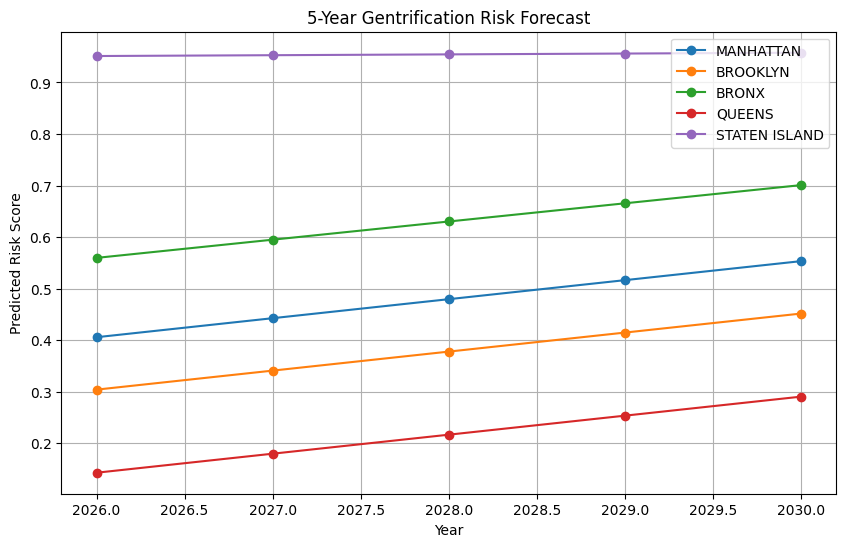

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for borough in forecast_df['borough'].unique():
    temp = forecast_df[forecast_df['borough'] == borough]
    plt.plot(temp['year'], temp['predicted_risk'], marker='o', label=borough)

plt.title("5-Year Gentrification Risk Forecast")
plt.xlabel("Year")
plt.ylabel("Predicted Risk Score")
plt.legend()
plt.grid(True)
plt.show()

CURRENT RISK VISUALIZATION

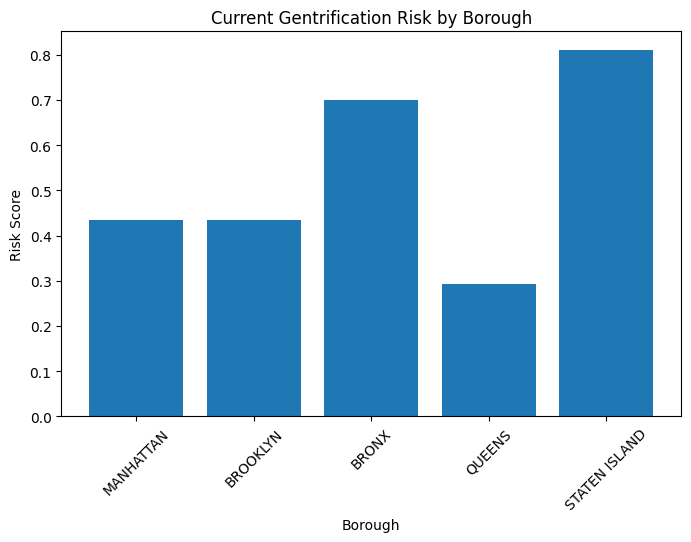

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df['borough'], df['gentrification_risk'])
plt.title("Current Gentrification Risk by Borough")
plt.xlabel("Borough")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()

GEOSPATIAL VISUALIZATION

In [ ]:
import folium
from folium.plugins import FeatureGroupSubGroup


In [ ]:
# Borough coordinates
borough_coords = {
    'MANHATTAN': (40.7831, -73.9712),
    'BROOKLYN': (40.6782, -73.9442),
    'BRONX': (40.8448, -73.8648),
    'QUEENS': (40.7282, -73.7949),
    'STATEN ISLAND': (40.5795, -74.1502)
}

# Base Map
m = folium.Map(location=[40.75, -73.95], zoom_start=10)

# Layer for current risk
current_layer = folium.FeatureGroup(name="Current Risk").add_to(m)

# Add current risk markers
for _, row in df.iterrows():
    borough = row['borough']
    risk = row['gentrification_risk']
    level = row['risk_level']
    dominant = row['dominant_risk_driver']

    # Color logic
    if level == "Very High":
        color = "red"
    elif level == "High":
        color = "orange"
    elif level == "Medium":
        color = "blue"
    else:
        color = "green"

    folium.CircleMarker(
        location=borough_coords[borough],
        radius=15 + risk*20,
        popup=f"""
        <b>{borough}</b><br>
        Current Risk: {risk:.2f}<br>
        Risk Level: {level}<br>
        Dominant Driver: {dominant}
        """,
        color=color,
        fill=True,
        fill_color=color
    ).add_to(current_layer)

# Create yearly forecast layers
years = forecast_df['year'].unique()

for year in years:
    year_layer = folium.FeatureGroup(name=f"Forecast {year}").add_to(m)

    temp_df = forecast_df[forecast_df['year'] == year]

    for _, row in temp_df.iterrows():
        borough = row['borough']
        risk = row['predicted_risk']

        # Dynamic color scale
        if risk >= 0.75:
            color = "darkred"
        elif risk >= 0.60:
            color = "red"
        elif risk >= 0.40:
            color = "orange"
        else:
            color = "green"

        folium.CircleMarker(
            location=borough_coords[borough],
            radius=15 + risk*20,
            popup=f"""
            <b>{borough}</b><br>
            Forecast Year: {year}<br>
            Predicted Risk: {risk:.2f}
            """,
            color=color,
            fill=True,
            fill_color=color
        ).add_to(year_layer)

# Add layer control
folium.LayerControl(collapsed=False).add_to(m)

m

In [ ]:
# Vulnerability Index (inverse income + unemployment)

df['income_vulnerability'] = 1 - df['income_norm']
df['unemployment_vulnerability'] = df['unemployment_norm']

df['vulnerability_index'] = (
    0.6 * df['income_vulnerability'] +
    0.4 * df['unemployment_vulnerability']
)

df[['borough','vulnerability_index']]

,borough,vulnerability_index
0,MANHATTAN,0.597843
1,BROOKLYN,0.502479
2,BRONX,0.556243
3,QUEENS,0.269175
4,STATEN ISLAND,0.600000


In [ ]:
df['displacement_risk'] = df['gentrification_risk'] * df['vulnerability_index']

df[['borough','gentrification_risk','vulnerability_index','displacement_risk']]

,borough,gentrification_risk,vulnerability_index,displacement_risk
0,MANHATTAN,0.435131,0.597843,0.260140
1,BROOKLYN,0.433930,0.502479,0.218040
2,BRONX,0.700346,0.556243,0.389563
3,QUEENS,0.292531,0.269175,0.078742
4,STATEN ISLAND,0.811299,0.600000,0.486780


In [ ]:
def impact_level(score):
    if score >= 0.60:
        return "Severe"
    elif score >= 0.40:
        return "Moderate"
    else:
        return "Low"

df['impact_severity'] = df['displacement_risk'].apply(impact_level)

df[['borough','impact_severity']]

,borough,impact_severity
0,MANHATTAN,Low
1,BROOKLYN,Low
2,BRONX,Low
3,QUEENS,Low
4,STATEN ISLAND,Moderate


In [ ]:
def policy_recommendation(level):
    if level == "Severe":
        return "Immediate anti-displacement housing policy required"
    elif level == "Moderate":
        return "Monitor affordability & introduce rent stabilization"
    else:
        return "Development stable – no urgent intervention"

df['policy_action'] = df['impact_severity'].apply(policy_recommendation)

df[['borough','impact_severity','policy_action']]

,borough,impact_severity,policy_action
0,MANHATTAN,Low,Development stable – no urgent intervention
1,BROOKLYN,Low,Development stable – no urgent intervention
2,BRONX,Low,Development stable – no urgent intervention
3,QUEENS,Low,Development stable – no urgent intervention
4,STATEN ISLAND,Moderate,Monitor affordability & introduce rent stabili...


In [ ]:
def simulate_scenario(
    crime_change=0,
    permit_change=0,
    income_growth_change=0,
    unemployment_change=0,
    transit_change=0
):

    sim_df = df.copy()

    # Apply changes (percentage based)
    sim_df['crime_norm_sim'] = sim_df['crime_norm'] * (1 + crime_change)
    sim_df['permit_norm_sim'] = sim_df['permit_norm'] * (1 + permit_change)
    sim_df['growth_norm_sim'] = sim_df['growth_norm'] * (1 + income_growth_change)
    sim_df['unemployment_norm_sim'] = sim_df['unemployment_norm'] * (1 + unemployment_change)
    sim_df['transit_norm_sim'] = sim_df['transit_norm'] * (1 + transit_change)

    # Clamp between 0 and 1
    for col in ['crime_norm_sim','permit_norm_sim','growth_norm_sim',
                'unemployment_norm_sim','transit_norm_sim']:
        sim_df[col] = sim_df[col].clip(0,1)

    # Recalculate derived indices
    sim_df['safety_sim'] = 1 - sim_df['crime_norm_sim']
    sim_df['economic_strength_sim'] = 1 - sim_df['unemployment_norm_sim']

    # Recalculate risk
    sim_df['simulated_risk'] = (
        0.25 * sim_df['permit_norm_sim'] +
        0.20 * sim_df['growth_norm_sim'] +
        0.15 * sim_df['economic_strength_sim'] +
        0.20 * sim_df['transit_norm_sim'] +
        0.20 * sim_df['safety_sim']
    )

    return sim_df[['borough','gentrification_risk','simulated_risk']]

In [ ]:
simulate_scenario(
    crime_change=-0.10,
    permit_change=0.15,
    transit_change=0.05
)

,borough,gentrification_risk,simulated_risk
0,MANHATTAN,0.435131,0.449677
1,BROOKLYN,0.433930,0.459231
2,BRONX,0.700346,0.700900
3,QUEENS,0.292531,0.276178
4,STATEN ISLAND,0.811299,0.811299


In [ ]:
simulate_scenario(
    unemployment_change=0.20,
    income_growth_change=-0.10
)

,borough,gentrification_risk,simulated_risk
0,MANHATTAN,0.435131,0.414431
1,BROOKLYN,0.433930,0.437579
2,BRONX,0.700346,0.655663
3,QUEENS,0.292531,0.253278
4,STATEN ISLAND,0.811299,0.810169


In [ ]:
simulate_scenario(
    transit_change=0.25
)

,borough,gentrification_risk,simulated_risk
0,MANHATTAN,0.435131,0.453827
1,BROOKLYN,0.433930,0.473486
2,BRONX,0.700346,0.697140
3,QUEENS,0.292531,0.276178
4,STATEN ISLAND,0.811299,0.811299


MONITORING

In [ ]:
# Extract forecast years
risk_2026 = forecast_df[forecast_df['year'] == 2026][['borough','predicted_risk']]
risk_2030 = forecast_df[forecast_df['year'] == 2030][['borough','predicted_risk']]

# Merge
acceleration_df = risk_2026.merge(risk_2030, on='borough', suffixes=('_2026','_2030'))

# Compute acceleration
acceleration_df['risk_acceleration'] = (
    acceleration_df['predicted_risk_2030'] -
    acceleration_df['predicted_risk_2026']
)

acceleration_df

,borough,predicted_risk_2026,predicted_risk_2030,risk_acceleration
0,MANHATTAN,0.405678,0.553267,0.147589
1,BROOKLYN,0.303989,0.451578,0.147589
2,BRONX,0.559584,0.700759,0.141176
3,QUEENS,0.142806,0.290395,0.147589
4,STATEN ISLAND,0.951179,0.957592,0.006413


In [ ]:
def generate_alert(row):

    alerts = []

    if row['gentrification_risk'] >= 0.75:
        alerts.append("High Current Risk")

    if row['risk_acceleration'] >= 0.15:
        alerts.append("Rapid Risk Growth")

    if row['displacement_risk'] >= 0.50:
        alerts.append("High Displacement Threat")

    if len(alerts) == 0:
        return "Stable"

    return " | ".join(alerts)

In [ ]:
df = df.merge(
    acceleration_df[['borough','risk_acceleration']],
    on='borough'
)

df['alert_status'] = df.apply(generate_alert, axis=1)

df[['borough','gentrification_risk','risk_acceleration',
    'displacement_risk','alert_status']]

,borough,gentrification_risk,risk_acceleration,displacement_risk,alert_status
0,MANHATTAN,0.435131,0.147589,0.260140,Stable
1,BROOKLYN,0.433930,0.147589,0.218040,Stable
2,BRONX,0.700346,0.141176,0.389563,Stable
3,QUEENS,0.292531,0.147589,0.078742,Stable
4,STATEN ISLAND,0.811299,0.006413,0.486780,High Current Risk
